# Notebook 2: Modeling

In [4]:
# ---------------------------------------------------------------------
# Imports and global settings
# ---------------------------------------------------------------------

from pathlib import Path
import warnings
from datetime import datetime
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    ExtraTreesClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier,
)
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GroupShuffleSplit,
    RandomizedSearchCV,
    StratifiedGroupKFold,
    StratifiedKFold,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from xgboost import XGBClassifier


# ---------------------------------------------------------------------
# Notebook settings
# ---------------------------------------------------------------------

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()
RANDOM_STATE = 42
PROD_THRESHOLD = 0.50
FINAL_FEATURE_COUNT = 25



## Helper Functions

In [5]:
# ---------------------------------------------------------------------
# Threshold table for business-facing model selection
# ---------------------------------------------------------------------

def make_threshold_table(y_true, y_proba, thresholds=np.arange(0.05, 0.65, 0.05)):
    rows = []

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan

        rows.append(
            {
                "threshold": threshold,
                "flagged_n": int(y_pred.sum()),
                "flagged_rate": y_pred.mean(),
                "sensitivity_recall": sensitivity,
                "specificity": specificity,
                "precision_ppv": ppv,
                "npv": npv,
                "f1": f1_score(y_true, y_pred, zero_division=0),
                "tp": tp,
                "fp": fp,
                "tn": tn,
                "fn": fn,
            }
        )

    return pd.DataFrame(rows)


## Load Data
Load the cohort dataframe from the feature generation notebook

In [6]:
cohort_df = pd.read_pickle('model_input_18052026.pkl')
cohort_df.head(5)

,first_name,last_name,sex,patient_id,visit_id,will_readmit,los_hours,ed_to_admit_hours,time_to_score_hours,age_at_prediction,...,map_bp_first_half,map_bp_second_half,map_bp_diff,pulse_pressure_first_half,pulse_pressure_second_half,pulse_pressure_diff,shock_index_first_half,shock_index_second_half,shock_index_diff,has_pre_prediction_vitals
0,Marcus,Gomez,male,00136717-0dff-4d43-ae3d-3e0ec1303bc3,506309de-b649-43f3-b57f-0f17f49f2998,False,120.0,4.0,18.733333,17.126561,...,91.629630,94.466667,2.837037,24.888889,15.8,-9.088889,0.669429,0.678447,0.009017,1
1,Aaron,Hill,male,001afe4c-8dd4-4e27-b22a-589568ccee5d,f92efacf-7d43-457b-a9ad-8c9ccbaa7708,False,144.0,1.0,1.100000,24.056062,...,81.333333,106.333333,25.000000,16.000000,10.0,-6.000000,0.717391,0.530973,-0.186418,1
2,Olivia,Cain,female,0026005d-1bbe-44c5-ba80-04d4ea3e63bc,3234c40a-d76c-48ee-8f51-4e8eaf638978,False,168.0,10.0,8.350000,76.217595,...,87.583333,91.533333,3.950000,15.250000,17.8,2.550000,0.724176,0.660527,-0.063649,1
3,Victoria,Diaz,female,0036e282-8248-4b26-b27d-b92de26eb295,8722ad61-c788-4695-937f-ec6224c9043a,False,48.0,10.0,0.983333,20.034159,...,98.666667,NaN,NaN,11.000000,NaN,NaN,0.622642,NaN,NaN,1
4,Peter,Lopez,male,00461a8f-5b9a-40eb-930e-20008cba2e01,f4e80f9a-5183-4dde-9a8d-a5b7d8e83cf3,False,24.0,23.0,1.983333,86.051955,...,97.333333,101.666667,4.333333,13.000000,17.0,4.000000,0.726415,0.522124,-0.204291,1


## Model training with class imbalance handling

### Dataframe formatting

In [7]:
# ---------------------------------------------------------------------
# Target and modeling dataframe
# ---------------------------------------------------------------------

target_col = "will_readmit"

# Work from cohort_df created in the feature generation notebook
cohort_model = cohort_df.copy()

# Convert target to binary integer
cohort_model[target_col] = cohort_model[target_col].astype(int)

# ---------------------------------------------------------------------
# Drop identifiers, duplicate labels, leakage fields, and redundant fields
# ---------------------------------------------------------------------

drop_cols = [
    # Labels / duplicate labels
    target_col,
    "target",

    # Identifiers / names
    "first_name",
    "last_name",
    "patient_id",
    "visit_id",

    # Leakage / unavailable at 6AM prediction time
    "los_hours",
    "time_to_score_hours",

    # Operational/redundant duration features
    "hours_observed",
    "obs_density",

    # Redundant or less stable highly correlated fields from EDA
    "vital_count",
    "prior_180d_visit_count",

    # Data-quality artifacts not used as clinical predictors
    "bp_swapped_rate",
    "temp_F_rate",
    "hr_oob_rate",
    "sbp_oob_rate",
    "dbp_oob_rate",
    "temp_oob_rate",

    # Older / duplicate prior-history features if present
    "prior_visits",
    "has_prior",
    "prev_target",
    "prev_discharge",
    "prior_readmits",
    "days_since_prev",
    "return30_flag",
    "return90_flag",

    # Redundant age fields if present
    "age_years",
    "age_group",
    "age_sq",

    # Raw timestamp fields if present
    "birth_date",
    "ed_arrival",
    "admission",
    "discharge",
    "score_time",
    "prediction_time",
    "first_vital_time",
    "last_vital_time",

    # Cohort definition / outcome artifacts if present
    "died",
    "died_flag",
    "eligible",
    "eligible_for_first_6am_score",
]

# Keep only columns that actually exist in cohort_df
drop_cols = [
    col for col in drop_cols
    if col in cohort_model.columns
]

# Separate predictors and target
X = cohort_model.drop(columns=drop_cols)
y = cohort_model[target_col]

# Patient groups used for leakage-safe splitting
groups = cohort_model["patient_id"]

print("Original cohort shape:", cohort_model.shape)
print("Modeling feature shape:", X.shape)
print("Target readmission rate:", y.mean())

Original cohort shape: (5297, 184)
Modeling feature shape: (5297, 174)
Target readmission rate: 0.11006229941476307


### Test/train split

In [8]:
# ---------------------------------------------------------------------
# Patient-level train/test split
# ---------------------------------------------------------------------

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42,
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Train readmit rate:", y_train.mean())
print("Test readmit rate:", y_test.mean())

# Confirm no patient appears in both train and test
train_patients = set(cohort_model.iloc[train_idx]["patient_id"])
test_patients = set(cohort_model.iloc[test_idx]["patient_id"])

print("Patient overlap between train/test:", len(train_patients & test_patients))

Train size: (4226, 174)
Test size: (1071, 174)
Train readmit rate: 0.10719356365357312
Test readmit rate: 0.12138188608776844
Patient overlap between train/test: 0


### Preprocessing

Logistic regression requires numeric scaling and imputation, while categorical variables must be encoded for all models. Although tree-based models such as Random Forest and XGBoost are generally robust to feature scaling, a shared preprocessing pipeline was used to ensure consistent handling of missing values and categorical features across all models.

In [9]:
# ---------------------------------------------------------------------
# Preprocessing
# ---------------------------------------------------------------------

numeric_features = X_train.select_dtypes(
    include=["number", "bool"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# Numeric features are imputed and scaled
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ]
)

# Categorical features are imputed and one-hot encoded
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

# Combine preprocessing by feature type
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 173
Categorical features: 1


### Class Imbalance Handling

Because 30-day readmission is less common than non-readmission, class imbalance handling was incorporated into all models.

- Logistic Regression used `class_weight="balanced"`
- Random Forest used `class_weight="balanced_subsample"`
- XGBoost used `scale_pos_weight` based on the ratio of negative to positive training examples

These approaches increase the penalty for misclassifying readmitted encounters and help improve minority-class sensitivity without requiring synthetic oversampling.

Alternatively we could have used SMOTE or random sampling.

In [10]:
# ---------------------------------------------------------------------
# Class imbalance handling
# ---------------------------------------------------------------------

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()

scale_pos_weight = neg_count / pos_count

print("Negative class count:", neg_count)
print("Positive class count:", pos_count)
print("XGBoost scale_pos_weight:", scale_pos_weight)

Negative class count: 3773
Positive class count: 453
XGBoost scale_pos_weight: 8.328918322295806


In [11]:
# ---------------------------------------------------------------------
# Models
# ---------------------------------------------------------------------

models = {
    # Interpretable baseline
    "logistic_regression_balanced": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs",
    ),

    # Nonlinear tree-based baseline
    "random_forest_balanced": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=10,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    ),

    # Boosted tree model with imbalance handling
    "xgboost_weighted": XGBClassifier(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
    ),
}

In [12]:
# ---------------------------------------------------------------------
# Evaluation helper
# ---------------------------------------------------------------------

def evaluate_model(name, pipe, X_eval, y_eval, threshold=0.50):
    """
    Evaluate a fitted binary classification pipeline.

    Parameters
    ----------
    name : str
        Model name.

    pipe : sklearn Pipeline
        Fitted preprocessing + model pipeline.

    X_eval : pd.DataFrame
        Evaluation features.

    y_eval : pd.Series
        True binary labels.

    threshold : float
        Probability threshold used to convert probabilities to class labels.

    Returns
    -------
    tuple
        Dictionary of metrics, predicted probabilities, and binary predictions.
    """

    # Predict readmission probabilities
    y_proba = pipe.predict_proba(X_eval)[:, 1]

    # Convert probabilities to binary predictions
    y_pred = (y_proba >= threshold).astype(int)

    # Confusion matrix components
    tn, fp, fn, tp = confusion_matrix(y_eval, y_pred).ravel()

    results = {
        "model": name,
        "threshold": threshold,
        "auroc": roc_auc_score(y_eval, y_proba),
        "auprc": average_precision_score(y_eval, y_proba),
        "precision": precision_score(y_eval, y_pred, zero_division=0),
        "recall": recall_score(y_eval, y_pred, zero_division=0),
        "specificity": tn / (tn + fp) if (tn + fp) > 0 else np.nan,
        "f1": f1_score(y_eval, y_pred, zero_division=0),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }

    return results, y_proba, y_pred

In [13]:
# ---------------------------------------------------------------------
# Train and evaluate all models
# ---------------------------------------------------------------------

all_results = []
predictions = {}

for name, model in models.items():
    print(f"Training {name}...")

    # Build full modeling pipeline
    pipe = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

    # Fit on training data only
    pipe.fit(X_train, y_train)

    # Evaluate on held-out test set
    results, y_proba, y_pred = evaluate_model(
        name=name,
        pipe=pipe,
        X_eval=X_test,
        y_eval=y_test,
        threshold=0.50,
    )

    all_results.append(results)

    # Store fitted pipeline and predictions
    predictions[name] = {
        "pipeline": pipe,
        "y_proba": y_proba,
        "y_pred": y_pred,
    }

# Summary table sorted by AUPRC
results_df = (
    pd.DataFrame(all_results)
    .sort_values("auprc", ascending=False)
    .reset_index(drop=True)
)

results_df

Training logistic_regression_balanced...
Training random_forest_balanced...
Training xgboost_weighted...


,model,threshold,auroc,auprc,precision,recall,specificity,f1,tn,fp,fn,tp
0,xgboost_weighted,0.5,0.994936,0.972019,0.789809,0.953846,0.964931,0.864111,908,33,6,124
1,random_forest_balanced,0.5,0.992422,0.957848,0.883721,0.876923,0.984060,0.880309,926,15,16,114
2,logistic_regression_balanced,0.5,0.970531,0.858256,0.594872,0.892308,0.916047,0.713846,862,79,14,116


### Hyperparameter Tuning

The initial baseline models performed very well, with XGBoost and Random Forest showing especially strong discrimination. Before selecting a final model, I performed a concise hyperparameter search to demonstrate whether performance could be improved while keeping the tuning process computationally reasonable.

The tuning step uses cross-validation and optimizes AUPRC, which is more informative than accuracy for an imbalanced readmission outcome.

In [14]:
# ---------------------------------------------------------------------
# Concise hyperparameter tuning
# ---------------------------------------------------------------------
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42,
)

In [15]:
# ---------------------------------------------------------------------
# Random Forest tuning
# ---------------------------------------------------------------------

rf_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            class_weight="balanced_subsample",
            random_state=42,
            n_jobs=-1,
        )),
    ]
)

rf_param_grid = {
    "model__n_estimators": [300, 500, 700],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_leaf": [5, 10, 20],
    "model__max_features": ["sqrt", "log2"],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_param_grid,
    n_iter=10,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train, y_train)

print("Best RF params:")
print(rf_search.best_params_)
print("Best RF CV AUPRC:", rf_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best RF params:
{'model__n_estimators': 500, 'model__min_samples_leaf': 10, 'model__max_features': 'sqrt', 'model__max_depth': None}
Best RF CV AUPRC: 0.945832141324491


In [16]:
# ---------------------------------------------------------------------
# XGBoost tuning
# ---------------------------------------------------------------------

xgb_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            n_jobs=-1,
        )),
    ]
)

xgb_param_grid = {
    "model__n_estimators": [200, 400, 600],
    "model__learning_rate": [0.01, 0.03, 0.05],
    "model__max_depth": [2, 3, 4],
    "model__min_child_weight": [1, 5, 10],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=xgb_param_grid,
    n_iter=15,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

xgb_search.fit(X_train, y_train)

print("Best XGB params:")
print(xgb_search.best_params_)
print("Best XGB CV AUPRC:", xgb_search.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best XGB params:
{'model__subsample': 1.0, 'model__n_estimators': 200, 'model__min_child_weight': 10, 'model__max_depth': 2, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}
Best XGB CV AUPRC: 0.954612081499946


In [17]:
# ---------------------------------------------------------------------
# Evaluate tuned models on held-out test set
# ---------------------------------------------------------------------

tuned_models = {
    "random_forest_tuned": rf_search.best_estimator_,
    "xgboost_tuned": xgb_search.best_estimator_,
}

tuned_results = []
tuned_predictions = {}

for name, pipe in tuned_models.items():
    results, y_proba, y_pred = evaluate_model(
        name=name,
        pipe=pipe,
        X_eval=X_test,
        y_eval=y_test,
        threshold=0.50,
    )

    tuned_results.append(results)

    tuned_predictions[name] = {
        "pipeline": pipe,
        "y_proba": y_proba,
        "y_pred": y_pred,
    }

tuned_results_df = (
    pd.DataFrame(tuned_results)
    .sort_values("auprc", ascending=False)
    .reset_index(drop=True)
)

tuned_results_df

,model,threshold,auroc,auprc,precision,recall,specificity,f1,tn,fp,fn,tp
0,xgboost_tuned,0.5,0.993722,0.967471,0.647668,0.961538,0.927736,0.773994,873,68,5,125
1,random_forest_tuned,0.5,0.992422,0.957848,0.883721,0.876923,0.984060,0.880309,926,15,16,114


### Final Model Selection Considerations

Although the tuned XGBoost model achieved the highest recall and lowest false negative count, it did so at the expense of substantially more false positives and lower precision.

The tuned Random Forest model achieved:
- Higher precision
- Higher F1-score
- Higher specificity
- Similar AUROC and AUPRC

while maintaining strong recall performance.

From an operational perspective, the Random Forest model produced a substantially cleaner alert stream with far fewer unnecessary flags while still identifying the majority of true readmissions. Because excessive false positives may contribute to clinician alert fatigue and reduce trust in deployment settings, the Random Forest model was selected as the preferred final model.

**Random Forest is more conservative and operationally efficient at threshold 0.50, but XGBoost may be the better clinical model because it catches 11 additional readmissions at the cost of 53 additional interventions. The final choice depends on whether the cost of one missed readmission is more than about 4.8x the cost of one unnecessary intervention.** For productionalization and model optimization I moved forward with RF, but the pruning techniques can easily be applied to the XGBoost if needed.

#### ROI for interventions vs missed readmissions

In [18]:
# XGBoost vs Random Forest at threshold 0.50

xgb_fn = 5
xgb_fp = 68

rf_fn = 16
rf_fp = 15

additional_fp_xgb = xgb_fp - rf_fp
avoided_fn_xgb = rf_fn - xgb_fn

cost_ratio_break_even = additional_fp_xgb / avoided_fn_xgb

cost_ratio_break_even

4.818181818181818

#### ROI Insights
XGBoost is better if the fine from 1 missed readmission > 4.82 * cost of 1 unnecessary intervention

## Optimize feature selections

In [19]:
# ---------------------------------------------------------------------
# Define selection_results_df for RF feature-selection comparison
# ---------------------------------------------------------------------
# Use fitted tuned RF pipeline
full_rf_pipe = rf_search.best_estimator_

# Pull fitted preprocessor and tuned RF model
fitted_preprocessor = full_rf_pipe.named_steps["preprocessor"]
fitted_rf = full_rf_pipe.named_steps["model"]

# Transform train/test data once
X_train_processed = fitted_preprocessor.transform(X_train)
X_test_processed = fitted_preprocessor.transform(X_test)

# Get processed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

original_feature_count = X_train_processed.shape[1]

print("Original processed feature count:", original_feature_count)

# Feature counts to evaluate
candidate_feature_counts = [10, 15, 20, 25, 30, 35, 40]

candidate_feature_counts = [
    k for k in candidate_feature_counts
    if k < original_feature_count
]

selection_results = []
selected_feature_sets = {}
threshold_tables = {}
selectors = {}
selected_models = {}

for k in candidate_feature_counts:
    print(f"Testing top {k} features...")

    # Select top-k features based on tuned RF importances
    selector = SelectFromModel(
        estimator=fitted_rf,
        prefit=True,
        max_features=k,
        threshold=-np.inf,
    )

    X_train_selected = selector.transform(X_train_processed)
    X_test_selected = selector.transform(X_test_processed)

    selected_features = feature_names[selector.get_support()]
    selected_feature_sets[k] = selected_features
    selectors[k] = selector

    # Train fresh RF using tuned hyperparameters on selected features
    selected_rf = RandomForestClassifier(
        n_estimators=fitted_rf.n_estimators,
        max_depth=fitted_rf.max_depth,
        min_samples_leaf=fitted_rf.min_samples_leaf,
        min_samples_split=fitted_rf.min_samples_split,
        max_features=fitted_rf.max_features,
        class_weight=fitted_rf.class_weight,
        random_state=42,
        n_jobs=-1,
    )

    selected_rf.fit(X_train_selected, y_train)
    selected_models[k] = selected_rf

    # Predict probabilities
    y_proba = selected_rf.predict_proba(X_test_selected)[:, 1]

    # Evaluate at production threshold
    threshold_df = make_threshold_table(
        y_true=y_test,
        y_proba=y_proba,
        thresholds=np.array([PROD_THRESHOLD]),
    )

    threshold_tables[k] = threshold_df
    threshold_row = threshold_df.iloc[0]

    selection_results.append({
        "n_selected_features": k,
        "auroc": roc_auc_score(y_test, y_proba),
        "auprc": average_precision_score(y_test, y_proba),
        "precision_ppv": threshold_row["precision_ppv"],
        "sensitivity_recall": threshold_row["sensitivity_recall"],
        "specificity": threshold_row["specificity"],
        "npv": threshold_row["npv"],
        "f1": threshold_row["f1"],
        "tp": threshold_row["tp"],
        "fp": threshold_row["fp"],
        "tn": threshold_row["tn"],
        "fn": threshold_row["fn"],
        "flagged_n": threshold_row["flagged_n"],
        "flagged_rate": threshold_row["flagged_rate"],
    })

# This is the missing dataframe
selection_results_df = (
    pd.DataFrame(selection_results)
    .sort_values(["n_selected_features"])
    .reset_index(drop=True)
)

selection_results_df

Original processed feature count: 323
Testing top 10 features...
Testing top 15 features...
Testing top 20 features...
Testing top 25 features...
Testing top 30 features...
Testing top 35 features...
Testing top 40 features...


,n_selected_features,auroc,auprc,precision_ppv,sensitivity_recall,specificity,npv,f1,tp,fp,tn,fn,flagged_n,flagged_rate
0,10,0.987141,0.929872,0.726708,0.900000,0.953241,0.985714,0.804124,117.0,44.0,897.0,13.0,161.0,0.150327
1,15,0.991098,0.949043,0.774834,0.900000,0.963868,0.985870,0.832740,117.0,34.0,907.0,13.0,151.0,0.140990
2,20,0.992300,0.953413,0.802721,0.907692,0.969182,0.987013,0.851986,118.0,29.0,912.0,12.0,147.0,0.137255
3,25,0.992888,0.957134,0.813793,0.907692,0.971307,0.987041,0.858182,118.0,27.0,914.0,12.0,145.0,0.135387
4,30,0.992896,0.957060,0.806897,0.900000,0.970244,0.985961,0.850909,117.0,28.0,913.0,13.0,145.0,0.135387
5,35,0.992872,0.956908,0.811189,0.892308,0.971307,0.984914,0.849817,116.0,27.0,914.0,14.0,143.0,0.133520
6,40,0.992324,0.954835,0.816901,0.892308,0.972370,0.984930,0.852941,116.0,26.0,915.0,14.0,142.0,0.132586


### Reduced Feature Set Selection

The 25-feature Random Forest model was selected as the preferred reduced model because it provided the best overall balance between performance and simplicity.

Compared with smaller feature sets, the 25-feature model achieved the strongest AUPRC and F1-score while maintaining high sensitivity and specificity. It captured 118 true readmissions, missed only 12 readmissions, and produced 27 false positives at the selected operating threshold.

Although the 30+ feature models have nearly identical AUROC, it did not improve AUPRC, recall, or F1-score compared with the 25-feature model. Larger feature sets also did not provide meaningful performance gains and slightly increased model complexity.

The 25-feature model therefore represents a practical tradeoff: it preserves the predictive performance of the larger feature sets while reducing the number of features that would need to be maintained, monitored, and productionalized.

## Save final model with 25 features

In [20]:
# Train and save final 25-feature Random Forest model

# ---------------------------------------------------------------------
# Select top 25 processed features
# ---------------------------------------------------------------------


selector = SelectFromModel(
    estimator=fitted_rf,
    prefit=True,
    max_features=FINAL_FEATURE_COUNT,
    threshold=-np.inf,
)

X_train_selected = selector.transform(X_train_processed)
X_test_selected = selector.transform(X_test_processed)

# ---------------------------------------------------------------------
# Clean feature names for readability
# ---------------------------------------------------------------------

selected_feature_names = [
    f.replace("num__", "").replace("cat__", "")
    for f in feature_names[selector.get_support()]
]

print("Selected features:")
print(selected_feature_names)

# ---------------------------------------------------------------------
# Train final RF model on selected features
# ---------------------------------------------------------------------

final_rf_25 = RandomForestClassifier(
    n_estimators=fitted_rf.n_estimators,
    max_depth=fitted_rf.max_depth,
    min_samples_leaf=fitted_rf.min_samples_leaf,
    min_samples_split=fitted_rf.min_samples_split,
    max_features=fitted_rf.max_features,
    class_weight=fitted_rf.class_weight,
    random_state=42,
    n_jobs=-1,
)

final_rf_25.fit(X_train_selected, y_train)

# ---------------------------------------------------------------------
# Build final inference object
# ---------------------------------------------------------------------
# Save everything needed for future inference:
# - fitted preprocessor
# - fitted feature selector
# - cleaned selected feature names
# - trained RF model
# - production threshold

final_model_bundle = {
    "preprocessor": fitted_preprocessor,
    "selector": selector,
    "selected_feature_names": selected_feature_names,
    "model": final_rf_25,
    "prod_threshold": PROD_THRESHOLD,
}

# ---------------------------------------------------------------------
# Save model
# ---------------------------------------------------------------------

timestamp = datetime.now().strftime("%d%m%Y")

model_filename = (
    f"readmission_rf_25_features_{timestamp}.joblib"
)

joblib.dump(final_model_bundle, model_filename)

print(f"Saved model to: {model_filename}")

Selected features:
['heart_rate_min', 'heart_rate_max', 'heart_rate_std', 'heart_rate_q10', 'heart_rate_q75', 'heart_rate_q90', 'heart_rate_range', 'heart_rate_iqr', 'heart_rate_cv', 'systolic_bp_min', 'diastolic_bp_min', 'diastolic_bp_q10', 'diastolic_bp_range', 'temperature_min', 'temperature_max', 'temperature_std', 'temperature_q10', 'temperature_q90', 'temperature_range', 'temperature_cv', 'map_bp_q10', 'shock_index_min', 'shock_index_std', 'shock_index_range', 'shock_index_cv']
Saved model to: readmission_rf_25_features_27052026.joblib


In [21]:
# Sanity check the save
loaded_model = joblib.load(
    "readmission_rf_25_features_19052026.joblib"
)

# View available objects
print(loaded_model.keys())

# View selected feature names
print(loaded_model["selected_feature_names"])

dict_keys(['preprocessor', 'selector', 'selected_feature_names', 'model', 'prod_threshold'])
['heart_rate_min', 'heart_rate_max', 'heart_rate_std', 'heart_rate_q10', 'heart_rate_q75', 'heart_rate_q90', 'heart_rate_range', 'heart_rate_iqr', 'heart_rate_cv', 'systolic_bp_min', 'diastolic_bp_min', 'diastolic_bp_q10', 'diastolic_bp_range', 'temperature_min', 'temperature_max', 'temperature_std', 'temperature_q10', 'temperature_q90', 'temperature_range', 'temperature_cv', 'map_bp_q10', 'shock_index_min', 'shock_index_std', 'shock_index_range', 'shock_index_cv']


## Feature Importance
SHAP

X_val_shap_sample shape: (500, 25)
SHAP values shape: (500, 25)


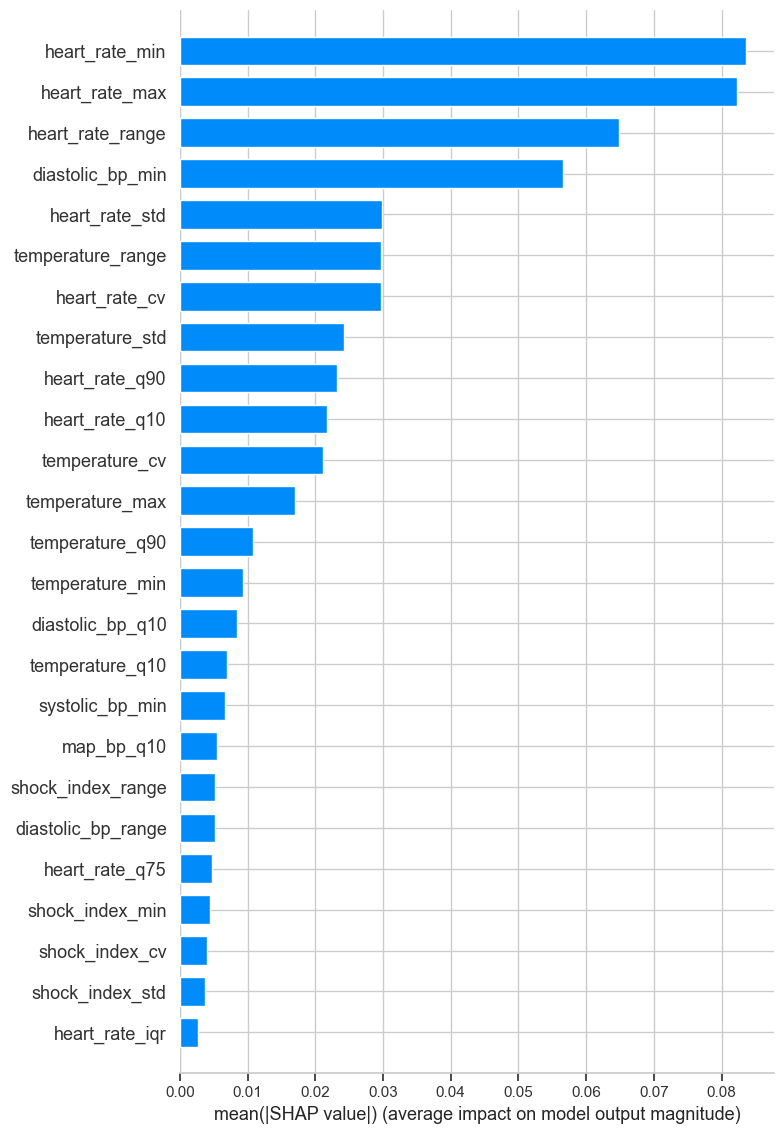

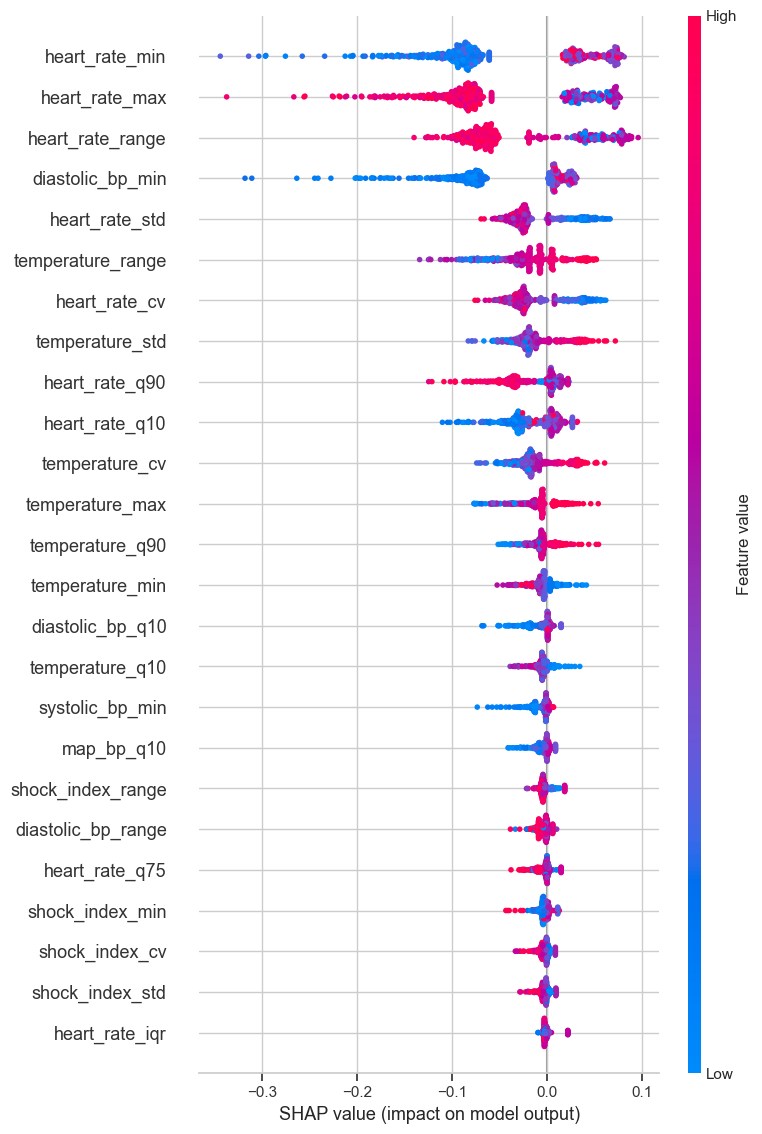

In [24]:
# ---------------------------------------------------------------------
# SHAP explanations for tuned RF 25-feature model
# ---------------------------------------------------------------------

rf_model = loaded_model["model"]
preprocessor = loaded_model["preprocessor"]
selector = loaded_model["selector"]
selected_feature_names = loaded_model["selected_feature_names"]

# 1. Preprocess
X_val_processed = preprocessor.transform(X_test)

if hasattr(X_val_processed, "toarray"):
    X_val_processed = X_val_processed.toarray()

# 2. Apply feature selector
X_val_selected = selector.transform(X_val_processed)

# 3. Use selected feature names only
X_val_shap = pd.DataFrame(
    X_val_selected,
    columns=selected_feature_names,
    index=X_test.index,
)

# 4. Sample for speed
X_val_shap_sample = X_val_shap.sample(
    n=min(500, len(X_val_shap)),
    random_state=42,
)

# 5. Explain final RF model
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_val_shap_sample)

if isinstance(shap_values, list):
    shap_values_readmit = shap_values[1]
elif len(np.array(shap_values).shape) == 3:
    shap_values_readmit = shap_values[:, :, 1]
else:
    shap_values_readmit = shap_values

print("X_val_shap_sample shape:", X_val_shap_sample.shape)
print("SHAP values shape:", shap_values_readmit.shape)

shap.summary_plot(
    shap_values_readmit,
    X_val_shap_sample,
    plot_type="bar",
    max_display=25,
    show=True,
)

shap.summary_plot(
    shap_values_readmit,
    X_val_shap_sample,
    max_display=25,
    show=True,
)

### SHAP Interpretation Summary

SHAP analysis of the tuned Random Forest model showed that the strongest predictors were pre-prediction vital sign summary features, particularly heart rate variability, heart rate extremes, temperature variability, minimum diastolic blood pressure, and shock index variability.

This aligns with the EDA findings, where variability-based features demonstrated stronger separation between readmitted and non-readmitted encounters than simple median values. The model appears to rely more on physiologic instability prior to the 6AM prediction time than on demographic variables or static encounter characteristics.

The most influential features were clinically plausible and available before prediction, which supports the deployment validity of the model. No obvious leakage features appeared among the top SHAP-ranked predictors.

#### Additional thoughts on feature importance
Note the importance of Temperature variability. Readmission signal may relate to systemic instability/infection-like patterns. It would be useful to pull in ICD10 and medication data into future versions of the model. Diastolic BP minimum matters. Lower DBP may indicate hemodynamic risk and could be signs of latent future cardiac events. No demographics in top features, which is consistent with EDA showing demographics were weak predictors. However, in future versions of the model I would highly recommend additional demographic features such as Race, Ethnicity, location, and social determinants of health (SDoH.)


## Fairness
Balanced classes do not guarentee equitable models. Below we will evaluate if our model performs equally well on females and males. We would include other potentially protected groups such as race and ethnicity if those were available in the dataset.

In [25]:
# ---------------------------------------------------------------------
# Fairness / equity evaluation for final Random Forest model
# Select model, threshold, and sensitive feature
# ---------------------------------------------------------------------
sensitive_col = "sex"

# Use tuned Random Forest as final model
final_pipe = final_rf_25

sensitive_train = (
    cohort_model
    .iloc[train_idx][sensitive_col]
    .reset_index(drop=True)
)

sensitive_test = (
    cohort_model
    .iloc[test_idx][sensitive_col]
    .reset_index(drop=True)
)

# ---------------------------------------------------------------------
# Preprocess and select final 25 features
# ---------------------------------------------------------------------

X_train_processed = fitted_preprocessor.transform(X_train)
X_test_processed = fitted_preprocessor.transform(X_test)

X_train_selected = selector.transform(X_train_processed)
X_test_selected = selector.transform(X_test_processed)

# ---------------------------------------------------------------------
# Predict probabilities using final 25-feature RF model
# ---------------------------------------------------------------------

y_train_proba = final_rf_25.predict_proba(X_train_selected)[:, 1]
y_test_proba = final_rf_25.predict_proba(X_test_selected)[:, 1]

# ---------------------------------------------------------------------
# Helper: group-level fairness metrics
# ---------------------------------------------------------------------

def fairness_table_by_group(
    y_true,
    y_proba,
    sensitive_features,
    sensitive_col,
    threshold=PROD_THRESHOLD,
):
    """
    Calculate threshold-based and probability-based model metrics by group.

    Uses make_threshold_table() so sensitivity, specificity, PPV, NPV,
    TP, FP, TN, FN, and flagged rate are calculated consistently with
    the model evaluation section.
    """

    df = pd.DataFrame({
        "y_true": pd.Series(y_true).reset_index(drop=True),
        "y_proba": y_proba,
        sensitive_col: pd.Series(sensitive_features).reset_index(drop=True),
    })

    rows = []

    for group_value, dfg in df.groupby(sensitive_col):
        threshold_df = make_threshold_table(
            y_true=dfg["y_true"],
            y_proba=dfg["y_proba"],
            thresholds=np.array([threshold]),
        )

        row = threshold_df.iloc[0].to_dict()

        # Add group metadata
        row.update({
            sensitive_col: group_value,
            "count": len(dfg),
            "prevalence": dfg["y_true"].mean(),
            "mean_score": dfg["y_proba"].mean(),
            "median_score": dfg["y_proba"].median(),
        })

        # AUROC requires both classes to be present
        if dfg["y_true"].nunique() < 2:
            row["auroc"] = np.nan
        else:
            row["auroc"] = roc_auc_score(
                dfg["y_true"],
                dfg["y_proba"],
            )

        row["auprc"] = average_precision_score(
            dfg["y_true"],
            dfg["y_proba"],
        )

        rows.append(row)

    return pd.DataFrame(rows)

# ---------------------------------------------------------------------
# Build train and test fairness tables
# ---------------------------------------------------------------------

train_group_metrics = fairness_table_by_group(
    y_true=y_train,
    y_proba=y_train_proba,
    sensitive_features=sensitive_train,
    sensitive_col=sensitive_col,
    threshold=PROD_THRESHOLD,
)

test_group_metrics = fairness_table_by_group(
    y_true=y_test,
    y_proba=y_test_proba,
    sensitive_features=sensitive_test,
    sensitive_col=sensitive_col,
    threshold=PROD_THRESHOLD,
)

print("Train group metrics:")
display(train_group_metrics)

print("Test group metrics:")
display(test_group_metrics)

# ---------------------------------------------------------------------
# Disparity summary: max-min difference and min/max ratio by metric
# ---------------------------------------------------------------------

fairness_metric_cols = [
    "prevalence",
    "mean_score",
    "median_score",
    "flagged_rate",
    "precision_ppv",
    "sensitivity_recall",
    "specificity",
    "npv",
    "f1",
    "auroc",
    "auprc",
]

def make_disparity_summary(group_df, split_name):
    """
    Summarize group-level disparities using absolute difference and ratio.
    """

    rows = []

    for metric in fairness_metric_cols:
        values = group_df[metric].dropna()

        if len(values) == 0:
            continue

        min_val = values.min()
        max_val = values.max()

        rows.append({
            "split": split_name,
            "metric": metric,
            "min": min_val,
            "max": max_val,
            "difference": max_val - min_val,
            "ratio": min_val / max_val if max_val != 0 else np.nan,
        })

    return pd.DataFrame(rows)

disparity_summary = pd.concat(
    [
        make_disparity_summary(train_group_metrics, "train"),
        make_disparity_summary(test_group_metrics, "test"),
    ],
    axis=0,
    ignore_index=True,
)

print("Disparity summary:")
display(disparity_summary)

Train group metrics:


,threshold,flagged_n,flagged_rate,sensitivity_recall,specificity,precision_ppv,npv,f1,tp,fp,tn,fn,sex,count,prevalence,mean_score,median_score,auroc,auprc
0,0.5,276.0,0.131931,0.975410,0.979437,0.862319,0.996696,0.915385,238.0,38.0,1810.0,6.0,female,2092,0.116635,0.157832,0.004588,0.998042,0.986304
1,0.5,237.0,0.111059,0.971292,0.982338,0.856540,0.996837,0.910314,203.0,34.0,1891.0,6.0,male,2134,0.097938,0.138661,0.003493,0.997784,0.979435


Test group metrics:


,threshold,flagged_n,flagged_rate,sensitivity_recall,specificity,precision_ppv,npv,f1,tp,fp,tn,fn,sex,count,prevalence,mean_score,median_score,auroc,auprc
0,0.5,66.0,0.121547,0.887097,0.977131,0.833333,0.985325,0.859375,55.0,11.0,470.0,7.0,female,543,0.114180,0.154402,0.004403,0.991516,0.944863
1,0.5,79.0,0.149621,0.926471,0.965217,0.797468,0.988864,0.857143,63.0,16.0,444.0,5.0,male,528,0.128788,0.172136,0.006595,0.994086,0.967095


Disparity summary:


,split,metric,min,max,difference,ratio
0,train,prevalence,0.097938,0.116635,0.018697,0.839699
1,train,mean_score,0.138661,0.157832,0.019170,0.878539
2,train,median_score,0.003493,0.004588,0.001095,0.761308
3,train,flagged_rate,0.111059,0.131931,0.020872,0.841795
4,train,precision_ppv,0.856540,0.862319,0.005779,0.993299
5,train,sensitivity_recall,0.971292,0.975410,0.004118,0.995778
6,train,specificity,0.979437,0.982338,0.002900,0.997047
7,train,npv,0.996696,0.996837,0.000141,0.999858
8,train,f1,0.910314,0.915385,0.005071,0.994461
9,train,auroc,0.997784,0.998042,0.000258,0.999742


## (Optional) Explore optimal threshold for RF model
The Random Forest model was evaluated across multiple probability thresholds to identify an operating point that balances readmission capture with alert burden. Lower thresholds increase sensitivity but flag more patients, while higher thresholds improve precision and specificity but miss more true readmissions. **One can see the model performs efficiently at a threshold of 0.50, so no need to adjust for production**

In [26]:
# ---------------------------------------------------------------------
# Threshold analysis for final 25-feature Random Forest model
# ---------------------------------------------------------------------

# Preprocess and select final 25 features
X_test_processed = fitted_preprocessor.transform(X_test)
X_test_selected = selector.transform(X_test_processed)

# Predict probabilities using final 25-feature RF model
rf_25_y_proba = final_rf_25.predict_proba(X_test_selected)[:, 1]

# Build threshold table
rf_25_threshold_df = make_threshold_table(
    y_true=y_test,
    y_proba=rf_25_y_proba,
    thresholds=np.arange(0.05, 0.95, 0.05),
)

rf_25_threshold_df

,threshold,flagged_n,flagged_rate,sensitivity_recall,specificity,precision_ppv,npv,f1,tp,fp,tn,fn
0,0.05,331,0.309057,1.000000,0.786397,0.392749,1.000000,0.563991,130,201,740,0
1,0.10,284,0.265173,1.000000,0.836344,0.457746,1.000000,0.628019,130,154,787,0
2,0.15,257,0.239963,1.000000,0.865037,0.505837,1.000000,0.671835,130,127,814,0
3,0.20,233,0.217554,1.000000,0.890542,0.557940,1.000000,0.716253,130,103,838,0
4,0.25,221,0.206349,1.000000,0.903294,0.588235,1.000000,0.740741,130,91,850,0
5,0.30,212,0.197946,0.992308,0.911796,0.608491,0.998836,0.754386,129,83,858,1
6,0.35,200,0.186741,0.976923,0.922423,0.635000,0.996556,0.769697,127,73,868,3
7,0.40,195,0.182073,0.976923,0.927736,0.651282,0.996575,0.781538,127,68,873,3
8,0.45,151,0.140990,0.915385,0.965994,0.788079,0.988043,0.846975,119,32,909,11
9,0.50,145,0.135387,0.907692,0.971307,0.813793,0.987041,0.858182,118,27,914,12
